In [1]:
import torch
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Python: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
PyTorch: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


In [2]:
import os
import sys
import time
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm import tqdm

# IMPORTANT:
# Replace with Praveen's personal required seed if the course specifies one.
SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

Python: 3.12.14
PyTorch: 2.13.0+cu130
Seed: 2026
Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 31.84 GB


In [3]:
SRC_DIR = Path.cwd()
MEMBER_DIR = SRC_DIR.parent
TASK_DIR = MEMBER_DIR.parent
PROJECT_ROOT = TASK_DIR.parent

DATA_DIR = TASK_DIR / "data"
PROCESSED_DIR = MEMBER_DIR / "data_processed"
CHECKPOINT_DIR = MEMBER_DIR / "checkpoints"
OUTPUT_DIR = MEMBER_DIR / "outputs"

for folder in [
    DATA_DIR,
    PROCESSED_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Source      :", SRC_DIR)
print("Member      :", MEMBER_DIR)
print("Task        :", TASK_DIR)
print("Data        :", DATA_DIR)
print("Processed   :", PROCESSED_DIR)
print("Checkpoints :", CHECKPOINT_DIR)
print("Outputs     :", OUTPUT_DIR)

Source      : D:\DATA266_Lab1\task1_llm\praveen\src
Member      : D:\DATA266_Lab1\task1_llm\praveen
Task        : D:\DATA266_Lab1\task1_llm
Data        : D:\DATA266_Lab1\task1_llm\data
Processed   : D:\DATA266_Lab1\task1_llm\praveen\data_processed
Checkpoints : D:\DATA266_Lab1\task1_llm\praveen\checkpoints
Outputs     : D:\DATA266_Lab1\task1_llm\praveen\outputs


In [4]:
print("Loading TinyStories...")

dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train"
)

print("\nDataset loaded.")
print(dataset)
print("Total stories:", len(dataset))
print("Columns:", dataset.column_names)

Loading TinyStories...



Dataset loaded.
Dataset({
    features: ['text'],
    num_rows: 2119719
})
Total stories: 2119719
Columns: ['text']


In [5]:
shuffled_dataset = dataset.shuffle(seed=SEED)

train_stories = shuffled_dataset.select(
    range(0, 100_000)
)

val_stories = shuffled_dataset.select(
    range(100_000, 110_000)
)

print("Training stories  :", len(train_stories))
print("Validation stories:", len(val_stories))

assert len(train_stories) == 100_000
assert len(val_stories) == 10_000

print("\nIndependent split PASSED.")

Training stories  : 100000
Validation stories: 10000

Independent split PASSED.


In [6]:
print("Building training character vocabulary...")

train_characters = set()

for story in tqdm(
    train_stories,
    desc="Scanning training stories"
):
    train_characters.update(story["text"])

chars = sorted(train_characters)

char_to_idx = {
    ch: i
    for i, ch in enumerate(chars)
}

idx_to_char = {
    i: ch
    for i, ch in enumerate(chars)
}

print("\nTraining vocabulary size:", len(chars))
print("First 30 characters:")
print(chars[:30])

Building training character vocabulary...


Scanning training stories: 100%|██████████| 100000/100000 [00:02<00:00, 46888.26it/s]


Training vocabulary size: 117
First 30 characters:
['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<']


In [7]:
val_characters = set()

for story in tqdm(
    val_stories,
    desc="Scanning validation stories"
):
    val_characters.update(story["text"])

unseen_chars = sorted(
    val_characters - train_characters
)

print("Unique training characters   :", len(train_characters))
print("Unique validation characters :", len(val_characters))
print("Validation-only characters   :", len(unseen_chars))

if unseen_chars:
    print("Unseen characters:", repr(unseen_chars))
else:
    print("No unseen validation characters.")

Scanning validation stories: 100%|██████████| 10000/10000 [00:00<00:00, 47368.27it/s]

Unique training characters   : 117
Unique validation characters : 93
Validation-only characters   : 2
Unseen characters: [']', 'Š']


In [8]:
UNK_TOKEN = "<UNK>"
UNK_IDX = len(char_to_idx)

char_to_idx[UNK_TOKEN] = UNK_IDX
idx_to_char[UNK_IDX] = UNK_TOKEN

VOCAB_SIZE = len(char_to_idx)

print("UNK index:", UNK_IDX)
print("Final vocabulary size:", VOCAB_SIZE)

UNK index: 117
Final vocabulary size: 118


In [9]:
def encode(text):
    return [
        char_to_idx.get(ch, UNK_IDX)
        for ch in text
    ]


def decode(indices):
    return "".join(
        idx_to_char[int(i)]
        for i in indices
    )


test_text = "Once upon a time!"

encoded_test = encode(test_text)
decoded_test = decode(encoded_test)

print("Original:", test_text)
print("Encoded :", encoded_test)
print("Decoded :", decoded_test)

assert decoded_test == test_text

print("\nTokenizer round-trip PASSED.")

Original: Once upon a time!
Encoded : [47, 74, 63, 65, 1, 81, 76, 75, 74, 1, 61, 1, 80, 69, 73, 65, 2]
Decoded : Once upon a time!

Tokenizer round-trip PASSED.


In [10]:
print("Combining stories...")

train_text = "\n\n".join(
    train_stories["text"]
)

val_text = "\n\n".join(
    val_stories["text"]
)

print(
    "Training characters  :",
    f"{len(train_text):,}"
)

print(
    "Validation characters:",
    f"{len(val_text):,}"
)

Combining stories...
Training characters  : 89,954,584
Validation characters: 8,971,053


In [11]:
print("Encoding training corpus...")

train_ids_np = np.fromiter(
    (
        char_to_idx.get(ch, UNK_IDX)
        for ch in train_text
    ),
    dtype=np.uint8,
    count=len(train_text)
)

print("Encoding validation corpus...")

val_ids_np = np.fromiter(
    (
        char_to_idx.get(ch, UNK_IDX)
        for ch in val_text
    ),
    dtype=np.uint8,
    count=len(val_text)
)

train_ids = torch.from_numpy(
    train_ids_np
)

val_ids = torch.from_numpy(
    val_ids_np
)

print("\nTrain tensor:", train_ids.shape)
print("Val tensor  :", val_ids.shape)

print(
    "Train storage:",
    round(
        train_ids.numel()
        * train_ids.element_size()
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "Val storage:",
    round(
        val_ids.numel()
        * val_ids.element_size()
        / 1024**2,
        2
    ),
    "MB"
)

Encoding training corpus...
Encoding validation corpus...

Train tensor: torch.Size([89954584])
Val tensor  : torch.Size([8971053])
Train storage: 85.79 MB
Val storage: 8.56 MB


In [12]:
train_ids_path = (
    PROCESSED_DIR / "train_ids.npy"
)

val_ids_path = (
    PROCESSED_DIR / "val_ids.npy"
)

np.save(
    train_ids_path,
    train_ids.numpy()
)

np.save(
    val_ids_path,
    val_ids.numpy()
)

print("Saved:")
print(train_ids_path)
print(val_ids_path)

Saved:
D:\DATA266_Lab1\task1_llm\praveen\data_processed\train_ids.npy
D:\DATA266_Lab1\task1_llm\praveen\data_processed\val_ids.npy


In [13]:
BLOCK_SIZE = 128
BATCH_SIZE = 192

N_EMBD = 192
N_HEAD = 6
N_LAYER = 3

FFN_MULT = 3
DROPOUT = 0.15

LEARNING_RATE = 4e-4
MIN_LR = 4e-5
WEIGHT_DECAY = 0.01

EPOCHS = 10
WARMUP_STEPS = 400

assert N_EMBD % N_HEAD == 0

HEAD_SIZE = N_EMBD // N_HEAD

print("Context length      :", BLOCK_SIZE)
print("Embedding dimension :", N_EMBD)
print("Attention heads     :", N_HEAD)
print("Head dimension      :", HEAD_SIZE)
print("Transformer blocks  :", N_LAYER)
print("FFN expansion       :", FFN_MULT)
print("Dropout             :", DROPOUT)
print("Batch size          :", BATCH_SIZE)
print("Initial LR          :", LEARNING_RATE)
print("Epochs              :", EPOCHS)

Context length      : 128
Embedding dimension : 192
Attention heads     : 6
Head dimension      : 32
Transformer blocks  : 3
FFN expansion       : 3
Dropout             : 0.15
Batch size          : 192
Initial LR          : 0.0004
Epochs              : 10


In [14]:
class CharSequenceDataset(Dataset):
    """
    Creates fixed-length character-level autoregressive
    input/target pairs.

    x = tokens[t : t + block_size]
    y = tokens[t + 1 : t + block_size + 1]
    """

    def __init__(self, token_ids, block_size, stride=None):
        self.token_ids = token_ids
        self.block_size = block_size

        self.stride = (
            stride
            if stride is not None
            else block_size
        )

        self.num_sequences = (
            (len(token_ids) - block_size - 1)
            // self.stride
        ) + 1

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start = idx * self.stride
        end = start + self.block_size

        x = self.token_ids[start:end].long()
        y = self.token_ids[start + 1:end + 1].long()

        return x, y

In [15]:
train_dataset = CharSequenceDataset(
    train_ids,
    block_size=BLOCK_SIZE
)

val_dataset = CharSequenceDataset(
    val_ids,
    block_size=BLOCK_SIZE
)

print("Block size           :", BLOCK_SIZE)
print("Training sequences   :", f"{len(train_dataset):,}")
print("Validation sequences :", f"{len(val_dataset):,}")

Block size           : 128
Training sequences   : 702,770
Validation sequences : 70,086


In [16]:
x, y = train_dataset[0]

print("Input shape :", x.shape)
print("Target shape:", y.shape)

print("\nINPUT:")
print(decode(x[:120]))

print("\nTARGET:")
print(decode(y[:120]))

print("\nFirst 10 input IDs :", x[:10].tolist())
print("First 10 target IDs:", y[:10].tolist())

assert x.shape == y.shape
assert len(x) == BLOCK_SIZE

print("\nAutoregressive sequence test PASSED.")

Input shape : torch.Size([128])
Target shape: torch.Size([128])

INPUT:
Sara and Tom are friends. They like to play with paint and paper. They have many colors of paint: red, blue, yellow, gre

TARGET:
ara and Tom are friends. They like to play with paint and paper. They have many colors of paint: red, blue, yellow, gree

First 10 input IDs : [51, 61, 78, 61, 1, 61, 74, 64, 1, 52]
First 10 target IDs: [61, 78, 61, 1, 61, 74, 64, 1, 52, 75]

Autoregressive sequence test PASSED.


In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("Training batches/epoch  :", len(train_loader))
print("Validation batches/epoch:", len(val_loader))

Training batches/epoch  : 3660
Validation batches/epoch: 366


In [18]:
xb, yb = next(iter(train_loader))

print("Input batch :", xb.shape)
print("Target batch:", yb.shape)
print("Input dtype :", xb.dtype)
print("Target dtype:", yb.dtype)

assert xb.shape == (
    BATCH_SIZE,
    BLOCK_SIZE
)

assert yb.shape == xb.shape
assert xb.dtype == torch.int64

print("\nDataLoader verification PASSED.")

Input batch : torch.Size([192, 128])
Target batch: torch.Size([192, 128])
Input dtype : torch.int64
Target dtype: torch.int64

DataLoader verification PASSED.


In [19]:
class FusedCausalSelfAttention(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head,
        block_size,
        dropout
    ):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_embd = n_embd
        self.n_head = n_head
        self.head_size = n_embd // n_head

        # One fused projection produces Q, K and V together
        self.qkv = nn.Linear(
            n_embd,
            3 * n_embd,
            bias=True
        )

        self.out_proj = nn.Linear(
            n_embd,
            n_embd
        )

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(
            torch.ones(
                block_size,
                block_size,
                dtype=torch.bool
            )
        )

        self.register_buffer(
            "causal_mask",
            mask.view(
                1,
                1,
                block_size,
                block_size
            )
        )

    def forward(self, x):

        B, T, C = x.shape

        # [B,T,C] -> [B,T,3C]
        qkv = self.qkv(x)

        # Separate Q, K, V
        q, k, v = qkv.chunk(
            3,
            dim=-1
        )

        # [B,T,C]
        # -> [B,H,T,D]
        q = q.view(
            B, T,
            self.n_head,
            self.head_size
        ).transpose(1, 2)

        k = k.view(
            B, T,
            self.n_head,
            self.head_size
        ).transpose(1, 2)

        v = v.view(
            B, T,
            self.n_head,
            self.head_size
        ).transpose(1, 2)

        # Scaled dot-product attention
        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(self.head_size)

        # Prevent attention to future positions
        scores = scores.masked_fill(
            ~self.causal_mask[:, :, :T, :T],
            float("-inf")
        )

        weights = F.softmax(
            scores,
            dim=-1
        )

        weights = self.attn_dropout(
            weights
        )

        out = weights @ v

        # [B,H,T,D] -> [B,T,C]
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(B, T, C)
        )

        out = self.out_proj(out)
        out = self.resid_dropout(out)

        return out

In [20]:
attention_test = FusedCausalSelfAttention(
    n_embd=N_EMBD,
    n_head=N_HEAD,
    block_size=BLOCK_SIZE,
    dropout=DROPOUT
).to(device)

dummy_x = torch.randn(
    2,
    BLOCK_SIZE,
    N_EMBD,
    device=device
)

with torch.no_grad():
    dummy_out = attention_test(dummy_x)

print("Input shape :", dummy_x.shape)
print("Output shape:", dummy_out.shape)

assert dummy_out.shape == dummy_x.shape

print("\nFused causal attention test PASSED.")

Input shape : torch.Size([2, 128, 192])
Output shape: torch.Size([2, 128, 192])

Fused causal attention test PASSED.


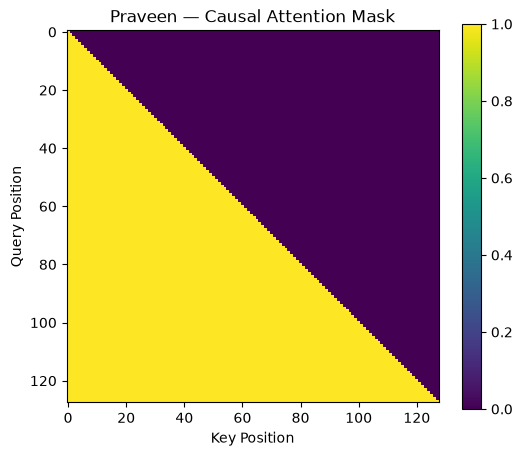

In [21]:
plt.figure(figsize=(6, 5))

plt.imshow(
    attention_test.causal_mask[
        0, 0
    ].cpu(),
    interpolation="nearest"
)

plt.title(
    "Praveen — Causal Attention Mask"
)
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.colorbar()
plt.show()

In [22]:
class FeedForward(nn.Module):

    def __init__(
        self,
        n_embd,
        expansion,
        dropout
    ):
        super().__init__()

        hidden_dim = (
            expansion * n_embd
        )

        self.net = nn.Sequential(
            nn.Linear(
                n_embd,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                n_embd
            ),

            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [23]:
class TransformerBlock(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head,
        block_size,
        ffn_mult,
        dropout
    ):
        super().__init__()

        self.ln1 = nn.LayerNorm(
            n_embd
        )

        self.attention = (
            FusedCausalSelfAttention(
                n_embd=n_embd,
                n_head=n_head,
                block_size=block_size,
                dropout=dropout
            )
        )

        self.ln2 = nn.LayerNorm(
            n_embd
        )

        self.ffn = FeedForward(
            n_embd=n_embd,
            expansion=ffn_mult,
            dropout=dropout
        )

    def forward(self, x):

        x = x + self.attention(
            self.ln1(x)
        )

        x = x + self.ffn(
            self.ln2(x)
        )

        return x

In [24]:
block_test = TransformerBlock(
    n_embd=N_EMBD,
    n_head=N_HEAD,
    block_size=BLOCK_SIZE,
    ffn_mult=FFN_MULT,
    dropout=DROPOUT
).to(device)

dummy_x = torch.randn(
    2,
    BLOCK_SIZE,
    N_EMBD,
    device=device
)

with torch.no_grad():
    dummy_out = block_test(
        dummy_x
    )

print(
    "Transformer input :",
    dummy_x.shape
)

print(
    "Transformer output:",
    dummy_out.shape
)

assert (
    dummy_x.shape
    == dummy_out.shape
)

print(
    "\nTransformer block test PASSED."
)

Transformer input : torch.Size([2, 128, 192])
Transformer output: torch.Size([2, 128, 192])

Transformer block test PASSED.


In [25]:
class GPTLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd,
        n_head,
        n_layer,
        ffn_mult,
        dropout
    ):
        super().__init__()

        self.block_size = block_size

        # Character token embedding
        self.token_embedding = nn.Embedding(
            vocab_size,
            n_embd
        )

        # Learnable positional embedding
        self.position_embedding = nn.Embedding(
            block_size,
            n_embd
        )

        # Stack of Praveen's Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                n_embd=n_embd,
                n_head=n_head,
                block_size=block_size,
                ffn_mult=ffn_mult,
                dropout=dropout
            )
            for _ in range(n_layer)
        ])

        self.final_norm = nn.LayerNorm(
            n_embd
        )

        # Language modeling head
        self.lm_head = nn.Linear(
            n_embd,
            vocab_size,
            bias=False
        )

        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )

        elif isinstance(module, nn.Embedding):

            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(
        self,
        idx,
        targets=None
    ):

        B, T = idx.shape

        if T > self.block_size:
            raise ValueError(
                f"Sequence length {T} exceeds "
                f"block size {self.block_size}"
            )

        positions = torch.arange(
            T,
            device=idx.device
        )

        token_emb = self.token_embedding(
            idx
        )

        pos_emb = self.position_embedding(
            positions
        )

        x = token_emb + pos_emb

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            B, T, V = logits.shape

            loss = F.cross_entropy(
                logits.reshape(B * T, V),
                targets.reshape(B * T)
            )

        return logits, loss

In [26]:
model = GPTLanguageModel(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_head=N_HEAD,
    n_layer=N_LAYER,
    ffn_mult=FFN_MULT,
    dropout=DROPOUT
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)

print(
    "\nTotal parameters    :",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

GPTLanguageModel(
  (token_embedding): Embedding(118, 192)
  (position_embedding): Embedding(128, 192)
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
      (attention): FusedCausalSelfAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (attn_dropout): Dropout(p=0.15, inplace=False)
        (resid_dropout): Dropout(p=0.15, inplace=False)
      )
      (ln2): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=576, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=576, out_features=192, bias=True)
          (3): Dropout(p=0.15, inplace=False)
        )
      )
    )
  )
  (final_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=T

In [27]:
xb, yb = next(
    iter(train_loader)
)

xb = xb.to(
    device,
    non_blocking=True
)

yb = yb.to(
    device,
    non_blocking=True
)

model.eval()

with torch.no_grad():

    logits, loss = model(
        xb,
        yb
    )

print(
    "Input shape :",
    xb.shape
)

print(
    "Logit shape :",
    logits.shape
)

print(
    "Initial loss:",
    round(loss.item(), 4)
)

assert logits.shape == (
    BATCH_SIZE,
    BLOCK_SIZE,
    VOCAB_SIZE
)

assert torch.isfinite(loss)

print(
    "\nFull GPT forward test PASSED."
)

Input shape : torch.Size([192, 128])
Logit shape : torch.Size([192, 128, 118])
Initial loss: 4.8474

Full GPT forward test PASSED.


In [28]:
model.train()

model.zero_grad(
    set_to_none=True
)

logits, loss = model(
    xb,
    yb
)

loss.backward()

grad_norm = (
    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )
)

print(
    "Loss:",
    round(loss.item(), 4)
)

print(
    "Gradient norm:",
    round(float(grad_norm), 4)
)

assert torch.isfinite(loss)
assert math.isfinite(
    float(grad_norm)
)

print(
    "\nForward + backward test PASSED."
)

model.zero_grad(
    set_to_none=True
)

Loss: 4.8374
Gradient norm: 6.2961

Forward + backward test PASSED.


In [29]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

TOTAL_STEPS = (
    EPOCHS
    * len(train_loader)
)

print(
    "Training batches / epoch:",
    len(train_loader)
)

print(
    "Epochs                  :",
    EPOCHS
)

print(
    "Total optimizer steps   :",
    TOTAL_STEPS
)

print(
    "Warmup steps            :",
    WARMUP_STEPS
)

Training batches / epoch: 3660
Epochs                  : 10
Total optimizer steps   : 36600
Warmup steps            : 400


In [30]:
def get_learning_rate(step):

    # Linear warm-up
    if step < WARMUP_STEPS:

        return (
            LEARNING_RATE
            * (step + 1)
            / WARMUP_STEPS
        )

    # Cosine decay
    decay_steps = (
        TOTAL_STEPS
        - WARMUP_STEPS
    )

    progress = (
        step
        - WARMUP_STEPS
    ) / decay_steps

    progress = min(
        max(progress, 0.0),
        1.0
    )

    cosine = 0.5 * (
        1.0
        + math.cos(
            math.pi * progress
        )
    )

    lr = (
        MIN_LR
        + cosine
        * (
            LEARNING_RATE
            - MIN_LR
        )
    )

    return lr

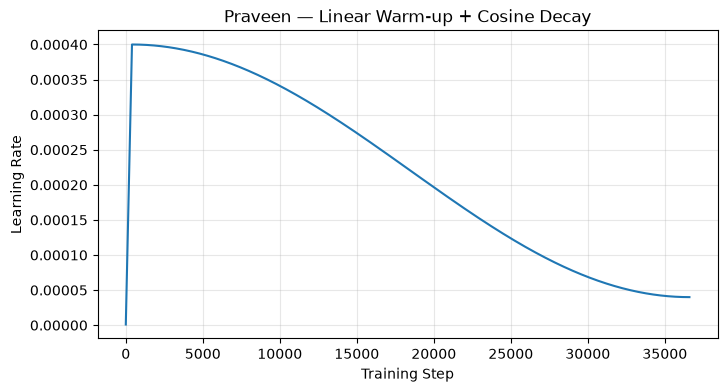

Initial LR: 1e-06
Warmup-end LR: 0.0004
Final LR: 4.000000067783675e-05


In [31]:
sample_steps = np.linspace(
    0,
    TOTAL_STEPS - 1,
    1000,
    dtype=int
)

sample_lrs = [
    get_learning_rate(step)
    for step in sample_steps
]

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    sample_steps,
    sample_lrs
)

plt.xlabel(
    "Training Step"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Praveen — Linear Warm-up + Cosine Decay"
)

plt.grid(
    alpha=0.3
)

plt.show()

print(
    "Initial LR:",
    get_learning_rate(0)
)

print(
    "Warmup-end LR:",
    get_learning_rate(
        WARMUP_STEPS - 1
    )
)

print(
    "Final LR:",
    get_learning_rate(
        TOTAL_STEPS - 1
    )
)

In [34]:
@torch.no_grad()
def evaluate(
    model,
    loader
):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for xb, yb in loader:

        xb = xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):

            logits, loss = model(
                xb,
                yb
            )

        num_tokens = yb.numel()

        total_loss += (
            loss.item()
            * num_tokens
        )

        predictions = logits.argmax(
            dim=-1
        )

        total_correct += (
            predictions == yb
        ).sum().item()

        total_tokens += num_tokens

    avg_loss = (
        total_loss
        / total_tokens
    )

    accuracy = (
        total_correct
        / total_tokens
    )

    model.train()

    return avg_loss, accuracy

In [35]:
BENCHMARK_STEPS = 200

model.train()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

benchmark_start = time.time()

benchmark_tokens = 0

optimizer.zero_grad(
    set_to_none=True
)

for step, (xb, yb) in enumerate(
    train_loader
):

    if step >= BENCHMARK_STEPS:
        break

    xb = xb.to(
        device,
        non_blocking=True
    )

    yb = yb.to(
        device,
        non_blocking=True
    )

    current_lr = get_learning_rate(
        step
    )

    for param_group in optimizer.param_groups:
        param_group["lr"] = current_lr

    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16
    ):

        logits, loss = model(
            xb,
            yb
        )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    optimizer.zero_grad(
        set_to_none=True
    )

    benchmark_tokens += (
        yb.numel()
    )

torch.cuda.synchronize()

benchmark_time = (
    time.time()
    - benchmark_start
)

training_tokens_sec = (
    benchmark_tokens
    / benchmark_time
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

estimated_epoch_sec = (
    benchmark_time
    / BENCHMARK_STEPS
    * len(train_loader)
)

estimated_10_epoch_hours = (
    estimated_epoch_sec
    * EPOCHS
    / 3600
)

print(
    "Benchmark steps       :",
    BENCHMARK_STEPS
)

print(
    "Benchmark time        :",
    round(
        benchmark_time,
        2
    ),
    "sec"
)

print(
    "Training tokens/sec   :",
    f"{training_tokens_sec:,.0f}"
)

print(
    "Peak GPU memory       :",
    round(
        peak_memory_gb,
        2
    ),
    "GB"
)

print(
    "Estimated epoch time  :",
    round(
        estimated_epoch_sec / 60,
        2
    ),
    "minutes"
)

print(
    "Estimated 10-epoch time:",
    round(
        estimated_10_epoch_hours,
        2
    ),
    "hours"
)

Benchmark steps       : 200
Benchmark time        : 2.0 sec
Training tokens/sec   : 2,456,478
Peak GPU memory       : 1.01 GB
Estimated epoch time  : 0.61 minutes
Estimated 10-epoch time: 0.1 hours


In [36]:
# ============================================================
# CLEAN RESET BEFORE OFFICIAL TRAINING
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Remove benchmark/test model objects
for name in [
    "model",
    "optimizer",
    "attention_test",
    "block_test",
    "dummy_x",
    "dummy_out",
    "xb",
    "yb"
]:
    if name in globals():
        del globals()[name]

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Recreate fresh model
model = GPTLanguageModel(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_embd=N_EMBD,
    n_head=N_HEAD,
    n_layer=N_LAYER,
    ffn_mult=FFN_MULT,
    dropout=DROPOUT
).to(device)

# Fresh optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

TOTAL_STEPS = EPOCHS * len(train_loader)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

print("OFFICIAL PRAVEEN RUN")
print("=" * 50)
print("Epochs           :", EPOCHS)
print("Steps / epoch    :", len(train_loader))
print("Total steps      :", TOTAL_STEPS)
print("Warmup steps     :", WARMUP_STEPS)
print("Parameter count  :", f"{parameter_count:,}")
print("GPU              :", torch.cuda.get_device_name(0))

OFFICIAL PRAVEEN RUN
Epochs           : 10
Steps / epoch    : 3660
Total steps      : 36600
Warmup steps     : 400
Parameter count  : 1,183,104
GPU              : NVIDIA GeForce RTX 5090


In [37]:
RAW_LOG_DIR = (
    PROJECT_ROOT
    / "reproducibility"
    / "raw_logs"
)

RAW_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOG_PATH = (
    RAW_LOG_DIR
    / "task1_llm_praveen_training_raw.txt"
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "task1_gpt_praveen_best.pt"
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "task1_gpt_praveen_last.pt"
)

HISTORY_PATH = (
    MEMBER_DIR
    / "task1_training_history.csv"
)

print("Raw log    :", LOG_PATH)
print("Best model :", BEST_CHECKPOINT_PATH)
print("Last model :", LAST_CHECKPOINT_PATH)
print("History    :", HISTORY_PATH)

Raw log    : D:\DATA266_Lab1\reproducibility\raw_logs\task1_llm_praveen_training_raw.txt
Best model : D:\DATA266_Lab1\task1_llm\praveen\checkpoints\task1_gpt_praveen_best.pt
Last model : D:\DATA266_Lab1\task1_llm\praveen\checkpoints\task1_gpt_praveen_last.pt
History    : D:\DATA266_Lab1\task1_llm\praveen\task1_training_history.csv


In [38]:
training_history = []

best_val_loss = float("inf")
global_step = 0

training_start_time = time.time()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Fresh raw log
with open(
    LOG_PATH,
    "w",
    encoding="utf-8"
) as log_file:

    log_file.write(
        "DATA266 Lab 1 - Task 1 - Praveen Official Training Run\n"
    )

    log_file.write(
        "=" * 70 + "\n"
    )

    log_file.write(f"Epochs: {EPOCHS}\n")
    log_file.write(f"Batch size: {BATCH_SIZE}\n")
    log_file.write(f"Block size: {BLOCK_SIZE}\n")
    log_file.write(f"Embedding dimension: {N_EMBD}\n")
    log_file.write(f"Attention heads: {N_HEAD}\n")
    log_file.write(f"Transformer layers: {N_LAYER}\n")
    log_file.write(f"FFN multiplier: {FFN_MULT}\n")
    log_file.write(f"Dropout: {DROPOUT}\n")
    log_file.write(f"Learning rate: {LEARNING_RATE}\n")
    log_file.write(f"Warmup steps: {WARMUP_STEPS}\n")
    log_file.write(f"Seed: {SEED}\n")
    log_file.write(
        f"GPU: {torch.cuda.get_device_name(0)}\n"
    )

    log_file.write(
        "=" * 70 + "\n\n"
    )


for epoch in range(
    1,
    EPOCHS + 1
):

    model.train()

    epoch_start = time.time()

    running_loss = 0.0
    total_train_tokens = 0

    grad_norm_sum = 0.0
    grad_norm_count = 0

    nan_count = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS}"
    )

    for xb, yb in progress:

        xb = xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        # Learning rate schedule
        current_lr = get_learning_rate(
            global_step
        )

        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):

            logits, loss = model(
                xb,
                yb
            )

        # Detect numerical problems
        if not torch.isfinite(loss):
            nan_count += 1
            raise RuntimeError(
                f"Non-finite loss detected at "
                f"epoch {epoch}, step {global_step}"
            )

        loss.backward()

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
        )

        optimizer.step()

        num_tokens = yb.numel()

        running_loss += (
            loss.item()
            * num_tokens
        )

        total_train_tokens += (
            num_tokens
        )

        grad_norm_sum += float(
            grad_norm
        )

        grad_norm_count += 1

        global_step += 1

        progress.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_lr:.2e}"
        )

    torch.cuda.synchronize()

    epoch_train_time = (
        time.time()
        - epoch_start
    )

    train_loss = (
        running_loss
        / total_train_tokens
    )

    # -------------------------
    # Validation
    # -------------------------

    val_start = time.time()

    val_loss, val_accuracy = evaluate(
        model,
        val_loader
    )

    torch.cuda.synchronize()

    val_time = (
        time.time()
        - val_start
    )

    # -------------------------
    # Metrics
    # -------------------------

    perplexity = math.exp(
        val_loss
    )

    bits_per_character = (
        val_loss
        / math.log(2)
    )

    generalization_gap = (
        val_loss
        - train_loss
    )

    avg_grad_norm = (
        grad_norm_sum
        / grad_norm_count
    )

    tokens_per_sec = (
        total_train_tokens
        / epoch_train_time
    )

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_perplexity": perplexity,
        "bits_per_character": bits_per_character,
        "generalization_gap": generalization_gap,
        "val_top1_accuracy": val_accuracy,
        "avg_gradient_norm": avg_grad_norm,
        "nan_count": nan_count,
        "learning_rate": current_lr,
        "training_tokens_per_sec": tokens_per_sec,
        "epoch_train_seconds": epoch_train_time,
        "validation_seconds": val_time,
        "peak_gpu_memory_gb": peak_memory_gb
    }

    training_history.append(
        epoch_result
    )

    # Save after every epoch
    pd.DataFrame(
        training_history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # -------------------------
    # Best checkpoint
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    train_loss,

                "val_loss":
                    val_loss,

                "config": {
                    "vocab_size": VOCAB_SIZE,
                    "block_size": BLOCK_SIZE,
                    "n_embd": N_EMBD,
                    "n_head": N_HEAD,
                    "n_layer": N_LAYER,
                    "ffn_mult": FFN_MULT,
                    "dropout": DROPOUT
                },

                "char_to_idx":
                    char_to_idx,

                "idx_to_char":
                    idx_to_char
            },
            BEST_CHECKPOINT_PATH
        )

        best_marker = " <-- BEST"

    else:
        best_marker = ""

    # Always save latest checkpoint
    torch.save(
        {
            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "val_loss":
                val_loss,

            "global_step":
                global_step
        },
        LAST_CHECKPOINT_PATH
    )

    summary = (
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"PPL: {perplexity:.2f} | "
        f"BPC: {bits_per_character:.3f} | "
        f"Top-1: {val_accuracy*100:.2f}% | "
        f"Gap: {generalization_gap:.4f} | "
        f"Grad: {avg_grad_norm:.3f} | "
        f"Tokens/s: {tokens_per_sec:,.0f} | "
        f"Time: {epoch_train_time/60:.2f} min"
        f"{best_marker}"
    )

    print(
        "\n" + summary + "\n"
    )

    with open(
        LOG_PATH,
        "a",
        encoding="utf-8"
    ) as log_file:

        log_file.write(
            summary + "\n"
        )


torch.cuda.synchronize()

total_training_time = (
    time.time()
    - training_start_time
)

print("=" * 80)
print("PRAVEEN TRAINING COMPLETE")
print("=" * 80)

print(
    "Total training time:",
    round(
        total_training_time / 60,
        2
    ),
    "minutes"
)

print(
    "Best validation loss:",
    round(
        best_val_loss,
        4
    )
)

print(
    "Peak GPU memory:",
    round(
        torch.cuda.max_memory_allocated()
        / 1024**3,
        2
    ),
    "GB"
)

print(
    "Best checkpoint:",
    BEST_CHECKPOINT_PATH
)

print(
    "History CSV:",
    HISTORY_PATH
)

print(
    "Raw log:",
    LOG_PATH
)

Epoch 1/10: 100%|██████████| 3660/3660 [00:39<00:00, 92.43it/s, loss=0.9587, lr=3.93e-04]



Epoch 01/10 | Train Loss: 1.3193 | Val Loss: 0.9041 | PPL: 2.47 | BPC: 1.304 | Top-1: 71.64% | Gap: -0.4153 | Grad: 0.984 | Tokens/s: 2,271,559 | Time: 0.66 min <-- BEST



Epoch 2/10: 100%|██████████| 3660/3660 [00:39<00:00, 92.26it/s, loss=0.9176, lr=3.69e-04]



Epoch 02/10 | Train Loss: 0.9441 | Val Loss: 0.8449 | PPL: 2.33 | BPC: 1.219 | Top-1: 73.32% | Gap: -0.0992 | Grad: 0.554 | Tokens/s: 2,267,300 | Time: 0.66 min <-- BEST



Epoch 3/10: 100%|██████████| 3660/3660 [00:41<00:00, 88.23it/s, loss=0.8838, lr=3.29e-04]


...


Epoch 08/10 | Train Loss: 0.8314 | Val Loss: 0.7665 | PPL: 2.15 | BPC: 1.106 | Top-1: 75.75% | Gap: -0.0649 | Grad: 0.434 | Tokens/s: 2,188,881 | Time: 0.68 min <-- BEST



Epoch 9/10: 100%|██████████| 3660/3660 [00:40<00:00, 90.89it/s, loss=0.8264, lr=4.90e-05]



Epoch 09/10 | Train Loss: 0.8265 | Val Loss: 0.7640 | PPL: 2.15 | BPC: 1.102 | Top-1: 75.85% | Gap: -0.0625 | Grad: 0.437 | Tokens/s: 2,233,755 | Time: 0.67 min <-- BEST



Epoch 10/10: 100%|██████████| 3660/3660 [00:39<00:00, 92.96it/s, loss=0.8673, lr=4.00e-05]



Epoch 10/10 | Train Loss: 0.8237 | Val Loss: 0.7626 | PPL: 2.14 | BPC: 1.100 | Top-1: 75.89% | Gap: -0.0611 | Grad: 0.442 | Tokens/s: 2,284,409 | Time: 0.66 min <-- BEST

PRAVEEN TRAINING COMPLETE
Total training time: 6.95 minutes
Best validation loss: 0.7626
Peak GPU memory: 1.0 GB
Best checkpoint: D:\DATA266_Lab1\task1_llm\praveen\checkpoints\task1_gpt_praveen_best.pt
History CSV: D:\DATA266_Lab1\task1_llm\praveen\task1_training_history.csv
Raw log: D:\DATA266_Lab1\reproducibility\raw_logs\task1_llm_praveen_training_raw.txt


In [39]:
checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded best checkpoint.")
print("Best epoch:", checkpoint["epoch"])
print("Saved train loss:", round(checkpoint["train_loss"], 4))
print("Saved val loss:", round(checkpoint["val_loss"], 4))

Loaded best checkpoint.
Best epoch: 10
Saved train loss: 0.8237
Saved val loss: 0.7626


In [40]:
@torch.no_grad()
def evaluate_full(model, loader):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for xb, yb in tqdm(
        loader,
        desc="Final evaluation"
    ):

        xb = xb.to(
            device,
            non_blocking=True
        )

        yb = yb.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16
        ):
            logits, loss = model(
                xb,
                yb
            )

        num_tokens = yb.numel()

        total_loss += (
            loss.item()
            * num_tokens
        )

        total_correct += (
            logits.argmax(-1) == yb
        ).sum().item()

        total_tokens += num_tokens

    avg_loss = (
        total_loss
        / total_tokens
    )

    accuracy = (
        total_correct
        / total_tokens
    )

    return avg_loss, accuracy


final_train_loss, final_train_accuracy = evaluate_full(
    model,
    train_loader
)

final_val_loss, final_val_accuracy = evaluate_full(
    model,
    val_loader
)

final_generalization_gap = (
    final_val_loss
    - final_train_loss
)

final_perplexity = math.exp(
    final_val_loss
)

final_bpc = (
    final_val_loss
    / math.log(2)
)

print("\nFINAL COMPARABLE METRICS")
print("------------------------")
print("Train loss         :", round(final_train_loss, 4))
print("Validation loss    :", round(final_val_loss, 4))
print("Generalization gap :", round(final_generalization_gap, 4))
print("Validation PPL     :", round(final_perplexity, 4))
print("Validation BPC     :", round(final_bpc, 4))
print("Train Top-1        :", round(final_train_accuracy * 100, 2), "%")
print("Validation Top-1   :", round(final_val_accuracy * 100, 2), "%")

Final evaluation: 100%|██████████| 366/366 [00:01<00:00, 271.53it/s]


FINAL COMPARABLE METRICS
------------------------
Train loss         : 0.7603
Validation loss    : 0.7626
Generalization gap : 0.0022
Validation PPL     : 2.1438
Validation BPC     : 1.1001
Train Top-1        : 75.93 %
Validation Top-1   : 75.89 %


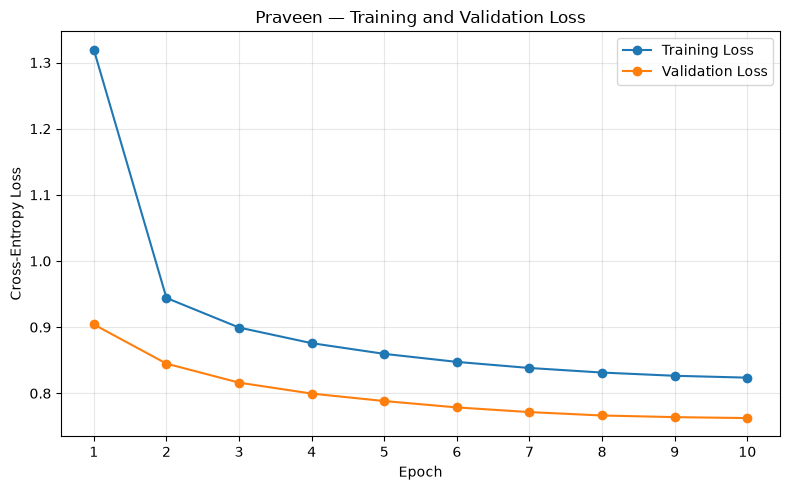

Saved: D:\DATA266_Lab1\task1_llm\praveen\outputs\train_val_loss_curve.png


In [41]:
history_df = pd.read_csv(
    HISTORY_PATH
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(
    "Praveen — Training and Validation Loss"
)

plt.xticks(
    history_df["epoch"]
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_CURVE_PATH = (
    OUTPUT_DIR
    / "train_val_loss_curve.png"
)

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_CURVE_PATH)

In [42]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=600,
    temperature=0.8,
    greedy=False
):

    model.eval()

    token_ids = encode(prompt)

    idx = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_count = 0

    torch.cuda.synchronize()

    start_time = time.time()

    for _ in range(
        max_new_tokens
    ):

        idx_cond = idx[
            :,
            -BLOCK_SIZE:
        ]

        logits, _ = model(
            idx_cond
        )

        logits = logits[
            :,
            -1,
            :
        ]

        if greedy:

            next_token = (
                torch.argmax(
                    logits,
                    dim=-1,
                    keepdim=True
                )
            )

        else:

            logits = (
                logits
                / temperature
            )

            probs = F.softmax(
                logits,
                dim=-1
            )

            next_token = (
                torch.multinomial(
                    probs,
                    num_samples=1
                )
            )

        idx = torch.cat(
            [idx, next_token],
            dim=1
        )

        generated_count += 1

    torch.cuda.synchronize()

    elapsed = (
        time.time()
        - start_time
    )

    generation_speed = (
        generated_count
        / elapsed
    )

    generated_text = decode(
        idx[0].tolist()
    )

    return (
        generated_text,
        generation_speed
    )

In [43]:
temperature_text, temperature_speed = generate_text(
    model,
    prompt="Once upon a time",
    max_new_tokens=700,
    temperature=0.8,
    greedy=False
)

print("TEMPERATURE SAMPLE")
print("=" * 80)
print(temperature_text)

print(
    "\nTemperature generation speed:",
    round(
        temperature_speed,
        2
    ),
    "tokens/sec"
)

TEMPERATURE SAMPLE
Once upon a time, there was a little boy named Timmy. Timmy loved to play outside in the garden with his friends. One day, Timmy's friends came over to play with the coin and saw that his friend drank was frustrated. They said, "Welcome, Lily. We are glad you like my boat and the lions. And you have to be careful and eat some fresh and snacks on the wall. You can stay still warm and sleep, and don't stay in the car," she says.

Tom and Sam are sad. They do not like to dance. They have no fun.

One day, they see a ball. It is a car full of trees. It is a toy car car. It has a big tree with flowers. Lily and Ben has a pink red tree. They see the red gun and the tree. They see a big tree in their pink boats. T

Temperature generation speed: 646.98 tokens/sec


In [44]:
greedy_text, greedy_speed = generate_text(
    model,
    prompt="Once upon a time",
    max_new_tokens=700,
    greedy=True
)

print("GREEDY SAMPLE")
print("=" * 80)
print(greedy_text)

print(
    "\nGreedy generation speed:",
    round(
        greedy_speed,
        2
    ),
    "tokens/sec"
)

GREEDY SAMPLE
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine and explore the world. One day, she went to the park with her mommy and daddy. They saw a big box of colorful pictures of a big box of colorful pictures of a big box. They were so happy that they had found a big box of colorful pictures of a big box. They were happy to have a big box of fun things together.

Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They saw a big box of colorful pictures of a big box of colorful pictures of a big box. They were so happy that they had found a big box of colorful pictures

Greedy generation speed: 797.72 tokens/sec


In [45]:
evaluation_prompts = [
    "Once upon a time",
    "One day, a little girl",
    "There was a little boy",
    "In a small village",
    "The dog looked at",
    "Lily went outside",
    "Tom was very excited",
    "The next morning",
]

generated_samples = []

for i, prompt in enumerate(
    evaluation_prompts,
    start=1
):

    text, speed = generate_text(
        model,
        prompt=prompt,
        max_new_tokens=600,
        temperature=0.8,
        greedy=False
    )

    generated_samples.append({
        "sample": i,
        "prompt": prompt,
        "text": text,
        "generation_tokens_per_sec": speed
    })

    print(
        f"Sample {i} complete."
    )

samples_df = pd.DataFrame(
    generated_samples
)

SAMPLES_PATH = (
    OUTPUT_DIR
    / "generated_samples.csv"
)

samples_df.to_csv(
    SAMPLES_PATH,
    index=False
)

print("\nSaved:", SAMPLES_PATH)

print(
    "Average generation speed:",
    round(
        samples_df[
            "generation_tokens_per_sec"
        ].mean(),
        2
    ),
    "tokens/sec"
)

Sample 1 complete.
Sample 2 complete.
Sample 3 complete.
Sample 4 complete.
Sample 5 complete.
Sample 6 complete.
Sample 7 complete.
Sample 8 complete.

Saved: D:\DATA266_Lab1\task1_llm\praveen\outputs\generated_samples.csv
Average generation speed: 691.14 tokens/sec


In [47]:
import re
from collections import Counter


def distinct_n(sequence, n):

    ngrams = [
        tuple(sequence[i:i+n])
        for i in range(
            len(sequence) - n + 1
        )
    ]

    if not ngrams:
        return 0.0

    return (
        len(set(ngrams))
        / len(ngrams)
    )


def repeated_ngram_rate(
    sequence,
    n=4
):

    ngrams = [
        tuple(sequence[i:i+n])
        for i in range(
            len(sequence) - n + 1
        )
    ]

    if not ngrams:
        return 0.0

    counts = Counter(
        ngrams
    )

    repeated_instances = sum(
        count - 1
        for count
        in counts.values()
        if count > 1
    )

    return (
        repeated_instances
        / len(ngrams)
    )


combined_generation = "\n".join(
    samples_df["text"]
)

char_sequence = list(
    combined_generation
)

char_distinct_1 = distinct_n(
    char_sequence,
    1
)

char_distinct_2 = distinct_n(
    char_sequence,
    2
)

char_distinct_3 = distinct_n(
    char_sequence,
    3
)

char_repeat_4 = repeated_ngram_rate(
    char_sequence,
    4
)

word_sequence = re.findall(
    r"\b\w+\b",
    combined_generation.lower()
)

word_distinct_1 = distinct_n(
    word_sequence,
    1
)

word_distinct_2 = distinct_n(
    word_sequence,
    2
)

word_distinct_3 = distinct_n(
    word_sequence,
    3
)

word_repeat_4 = repeated_ngram_rate(
    word_sequence,
    4
)

print("CHARACTER-LEVEL METRICS")
print("-----------------------")
print("Distinct-1      :", round(char_distinct_1, 4))
print("Distinct-2      :", round(char_distinct_2, 4))
print("Distinct-3      :", round(char_distinct_3, 4))
print("Repeated 4-gram :", round(char_repeat_4, 4))

print("\nWORD-LEVEL METRICS")
print("------------------")
print("Distinct-1      :", round(word_distinct_1, 4))
print("Distinct-2      :", round(word_distinct_2, 4))
print("Distinct-3      :", round(word_distinct_3, 4))
print("Repeated 4-gram :", round(word_repeat_4, 4))

CHARACTER-LEVEL METRICS
-----------------------
Distinct-1      : 0.0093
Distinct-2      : 0.082
Distinct-3      : 0.2463
Repeated 4-gram : 0.5765

WORD-LEVEL METRICS
------------------
Distinct-1      : 0.2838
Distinct-2      : 0.7414
Distinct-3      : 0.9069
Repeated 4-gram : 0.0304


In [49]:
best_epoch_row = history_df.loc[
    history_df["val_loss"].idxmin()
]

avg_training_tokens_sec = (
    history_df["training_tokens_per_sec"].mean()
)

avg_generation_tokens_sec = (
    samples_df["generation_tokens_per_sec"].mean()
)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

total_nan_count = int(
    history_df["nan_count"].sum()
)

train_loss_epoch_increases = int(
    (history_df["train_loss"].diff() > 0).sum()
)

val_loss_epoch_increases = int(
    (history_df["val_loss"].diff() > 0).sum()
)

total_training_time_minutes = (
    history_df["epoch_train_seconds"].sum()
    + history_df["validation_seconds"].sum()
) / 60

metrics_report = pd.DataFrame([
    {
        "best_epoch":
            int(checkpoint["epoch"]),

        "training_cross_entropy_loss":
            final_train_loss,

        "validation_cross_entropy_loss":
            final_val_loss,

        "perplexity":
            final_perplexity,

        "bits_per_character":
            final_bpc,

        "generalization_gap":
            final_generalization_gap,

        "train_top1_accuracy":
            final_train_accuracy,

        "validation_top1_accuracy":
            final_val_accuracy,

        "distinct_1_char":
            char_distinct_1,

        "distinct_2_char":
            char_distinct_2,

        "distinct_3_char":
            char_distinct_3,

        "repeated_4gram_rate_char":
            char_repeat_4,

        "distinct_1_word":
            word_distinct_1,

        "distinct_2_word":
            word_distinct_2,

        "distinct_3_word":
            word_distinct_3,

        "repeated_4gram_rate_word":
            word_repeat_4,

        "average_gradient_norm":
            best_epoch_row["avg_gradient_norm"],

        "nan_count":
            total_nan_count,

        "parameter_count":
            parameter_count,

        "training_tokens_per_sec":
            avg_training_tokens_sec,

        "generation_tokens_per_sec":
            avg_generation_tokens_sec,

        "peak_gpu_memory_gb":
            history_df["peak_gpu_memory_gb"].max(),

        "total_training_time_minutes":
            total_training_time_minutes,

        "gpu":
            torch.cuda.get_device_name(0)
    }
])

METRICS_PATH = (
    MEMBER_DIR
    / "metrics_report.csv"
)

metrics_report.to_csv(
    METRICS_PATH,
    index=False
)

display(metrics_report.T)

print("\nSaved:", METRICS_PATH)

,0
best_epoch,10
training_cross_entropy_loss,0.760322
validation_cross_entropy_loss,0.762563
perplexity,2.143764
bits_per_character,1.100146
generalization_gap,0.002241
train_top1_accuracy,0.759339
validation_top1_accuracy,0.758892
distinct_1_char,0.009284
distinct_2_char,0.081954



Saved: D:\DATA266_Lab1\task1_llm\praveen\metrics_report.csv


In [50]:
failure_analysis_path = (
    MEMBER_DIR
    / "failure_analysis.md"
)

failure_analysis_text = """# Task 1 — Sequence Model Failure Analysis

## Failure Case 1 — Strong Repetition in Greedy Decoding

**Generated behavior:**

The greedy sample produced nearly the same TinyStories-style passage twice, beginning with:

> "Once upon a time, there was a little girl named Lily..."

and repeating the same sequence involving the park and a box of colorful pictures.

**Failure type:** Repetition / decoding collapse

**Observation:**  
Greedy decoding always selects the highest-probability next character. This caused the model to repeatedly fall into a high-probability story template rather than generating diverse continuations.

---

## Failure Case 2 — Semantic Inconsistency

**Generated snippet:**

> "You have to be careful and eat some fresh and snacks on the wall."

**Failure type:** Semantic incoherence

**Observation:**  
The sentence is locally grammatical in parts, but the complete meaning is inconsistent. The phrase "snacks on the wall" does not fit the surrounding story context. The model learned common word and sentence patterns without reliably preserving higher-level meaning.

---

## Failure Case 3 — Object / World-Logic Error

**Generated snippet:**

> "It is a car full of trees. It is a toy can car."

**Failure type:** Hallucination / loss of coherence

**Observation:**  
The generated text combines familiar nouns and sentence templates in ways that do not form a coherent real-world description. The shorter 128-character context and smaller model capacity may make longer-range semantic consistency more difficult.

---

## Overall Observation

The model learned TinyStories-style grammar and short narrative patterns well, but generation still shows two characteristic weaknesses.

Greedy decoding is highly deterministic and can repeat common templates. Temperature sampling increases diversity, but it also produces more semantic inconsistencies.

The relatively high character repeated 4-gram rate is consistent with the repetition visible in generated text.
"""

failure_analysis_path.write_text(
    failure_analysis_text,
    encoding="utf-8"
)

print("Saved:", failure_analysis_path)

Saved: D:\DATA266_Lab1\task1_llm\praveen\failure_analysis.md


In [51]:
results_path = (
    MEMBER_DIR
    / "results.md"
)

results_text = f"""# DATA266 Lab 1 — Task 1 Results

## Student

Praveen

## Model

Character-level GPT-style decoder-only language model implemented from scratch in PyTorch.

## Architecture

- Vocabulary size: {VOCAB_SIZE}
- Context length: {BLOCK_SIZE}
- Embedding dimension: {N_EMBD}
- Attention heads: {N_HEAD}
- Dimension per head: {N_EMBD // N_HEAD}
- Transformer blocks: {N_LAYER}
- FFN expansion multiplier: {FFN_MULT}
- FFN hidden dimension: {FFN_MULT * N_EMBD}
- Dropout: {DROPOUT}
- Fused Q/K/V projection
- Learnable token embeddings
- Learnable positional embeddings
- Pre-LayerNorm Transformer blocks
- GELU feed-forward network
- Residual connections
- Linear language-model head
- Parameter count: {parameter_count:,}

No nn.MultiheadAttention, nn.Transformer, or pretrained Transformer model was used.

## Architecture Rationale

A 128-character context was chosen to reduce the quadratic cost of self-attention while still providing enough short-range context for TinyStories.

The 192-dimensional embedding is divided across 6 attention heads, giving 32 dimensions per head.

Three Transformer blocks and a 3x feed-forward expansion were selected to create a smaller and computationally efficient model while still retaining multiple stages of self-attention and nonlinear processing.

The fused Q/K/V projection provides a different attention implementation from the teammate model while still computing scaled dot-product multi-head causal self-attention manually.

## Dataset

Dataset: TinyStories

Independent deterministic split:

- Training stories: 100,000
- Validation stories: 10,000
- Training characters: {len(train_ids):,}
- Validation characters: {len(val_ids):,}
- Training character vocabulary: 117
- Final vocabulary including <UNK>: {VOCAB_SIZE}
- Validation-only unseen characters: 2

## Training

- Epochs: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Optimizer: AdamW
- Initial learning rate: {LEARNING_RATE}
- Minimum learning rate: {MIN_LR}
- Warm-up steps: {WARMUP_STEPS}
- Scheduler: linear warm-up followed by cosine decay
- Weight decay: {WEIGHT_DECAY}
- Gradient clipping: 1.0
- Mixed precision: BF16
- Seed: {SEED}

## Final Evaluation

| Metric | Result |
|---|---:|
| Training CE loss | {final_train_loss:.4f} |
| Validation CE loss | {final_val_loss:.4f} |
| Generalization gap | {final_generalization_gap:.4f} |
| Validation perplexity | {final_perplexity:.4f} |
| Bits per character | {final_bpc:.4f} |
| Train Top-1 accuracy | {final_train_accuracy * 100:.2f}% |
| Validation Top-1 accuracy | {final_val_accuracy * 100:.2f}% |
| Character Distinct-1 | {char_distinct_1:.4f} |
| Character Distinct-2 | {char_distinct_2:.4f} |
| Character Distinct-3 | {char_distinct_3:.4f} |
| Character repeated 4-gram rate | {char_repeat_4:.4f} |
| Word Distinct-1 | {word_distinct_1:.4f} |
| Word Distinct-2 | {word_distinct_2:.4f} |
| Word Distinct-3 | {word_distinct_3:.4f} |
| Word repeated 4-gram rate | {word_repeat_4:.4f} |
| Parameter count | {parameter_count:,} |
| Average training throughput | {avg_training_tokens_sec:,.0f} tokens/sec |
| Average generation throughput | {avg_generation_tokens_sec:.2f} tokens/sec |
| Peak GPU memory | {history_df["peak_gpu_memory_gb"].max():.2f} GB |
| Total training time | {total_training_time_minutes:.2f} min |
| NaN count | {total_nan_count} |

## Generation

Both greedy decoding and temperature-based sampling were evaluated.

Greedy decoding generated more deterministic but substantially more repetitive outputs.

Temperature sampling generated more diverse text, but several semantic and world-logic inconsistencies appeared.

Generated samples:

`outputs/generated_samples.csv`

## Failure Analysis

Three representative failure cases are documented in:

`failure_analysis.md`

## Hardware

GPU: NVIDIA GeForce RTX 5090
"""

results_path.write_text(
    results_text,
    encoding="utf-8"
)

print("Saved:", results_path)

Saved: D:\DATA266_Lab1\task1_llm\praveen\results.md


In [52]:
manifest_path = (
    PROJECT_ROOT
    / "reproducibility"
    / "manifests"
    / "task1_praveen_manifest.txt"
)

manifest_text = f"""DATA266 Lab 1 — Task 1 Manifest

Student: Praveen

Best checkpoint:
{BEST_CHECKPOINT_PATH}

Best epoch:
{checkpoint["epoch"]}

Metrics:
{METRICS_PATH}

Training history:
{HISTORY_PATH}

Raw training log:
{LOG_PATH}

Loss curve:
{LOSS_CURVE_PATH}

Generated samples:
{SAMPLES_PATH}

Failure analysis:
{failure_analysis_path}

Results summary:
{results_path}

Notebook:
{SRC_DIR / "Task1_LLM_Praveen.ipynb"}

GPU:
{torch.cuda.get_device_name(0)}
"""

manifest_path.write_text(
    manifest_text,
    encoding="utf-8"
)

print("Saved:", manifest_path)

Saved: D:\DATA266_Lab1\reproducibility\manifests\task1_praveen_manifest.txt
